In [1]:
import labrad
from labrad import units
import numpy as np
import matplotlib.pyplot as plt
from os import path
import sys
import imageio
import scipy.optimize as opt
from scipy.optimize import curve_fit
from scipy import signal
from pylablib.devices import Thorlabs
from PIL import Image
import time
# 


import datetime
from pathlib import Path
import imutils

_root = path.abspath(path.join(
    '//arqusws-01', 'ArQuS Shared', 'LabRAD', 'LabRADCodes', 'servers', 'Spectrum_Card'))
sys.path.append(_root)


# import wavegen as wg

#connecting to labrad
cxn = labrad.connect('192.168.1.21', password='ytterbium171')
PM = cxn.picomotors

In [2]:
PM.get_id()

'ÿû\x01ÿû\x03New_Focus 8742 v3.04 09/09/16 96481'

In [3]:
# import pylablib as pll
# pll.par["devices/dlls/thorlabs_tlcam"] = "C:/Program Files/Thorlabs/Scientific Imaging/ThorCam"
Thorlabs.list_cameras_tlcam()

['13286']

In [4]:
MHz = 1e6
Mako_G_234_B = False
Mako_G_158_B = False
Thor_Cam = True

THEORETICAL = False
EXP = True

if EXP == True:
    MAGNIFICATION = 34.2
    # MAGNIFICATION = 78
elif THEORETICAL == True:
    MAGNIFICATION = 300/9
    MAGNIFICATION = 300/4

TWEEZERS_NUMBER = 1

#define the grid of pixels
if Mako_G_234_B == True:
    PX = 5.86
if Thor_Cam or Mako_G_158_B == True:
    PX = 3.45

In [5]:
# SC = cxn.m4i_6621_x8
# PM = cxn.picomotors

if Thor_Cam == True:
    cam = Thorlabs.ThorlabsTLCamera(serial='13286')
    cam.set_exposure(0.064*1e-3) # in seconds
    px = 3.45
    
elif Mako_G_234_B or Mako_G_158_B == True:
    #set exposure time
    MC = cxn.mako_camera
    print(MC.exposure_time(16 * units.us))
    print(MC.pixel_format('Mono8'))
    print(MC.gain(0 * units.dB))
    print(MC.frame_size(1936, 1216))
    px = 5.86


In [6]:
#define fitting functions
def gaussian_2D(xdata_tuple, amp, x0, y0, sigma_x, sigma_y):
    (x, y) = xdata_tuple
    G = amp * np.exp(-2 * ((x - x0) ** 2 / sigma_x ** 2 + (y - y0) ** 2 / sigma_y ** 2))
    return G.ravel()

def sum_of_2D_gaussians(xdata_tuple, *params):
    n = len(params) // 5  # Each Gaussian has 5 parameters: amp, x0, y0, sigma_x, sigma_y
    G = 0
    for i in range(n):
        amp, x0, y0, sigma_x, sigma_y = params[i * 5: ((i + 1) * 5)]
        G += gaussian_2D(xdata_tuple, amp, x0, y0, sigma_x, sigma_y)
    return G.ravel()

In [7]:
PM.set_position_reference(1, 0)
PM.get_position('all')

array([0, 0, 0, 0])

In [8]:
# PM.relative_move(1, +20)



###########################
objective position: -500
###########################




Acquring image...




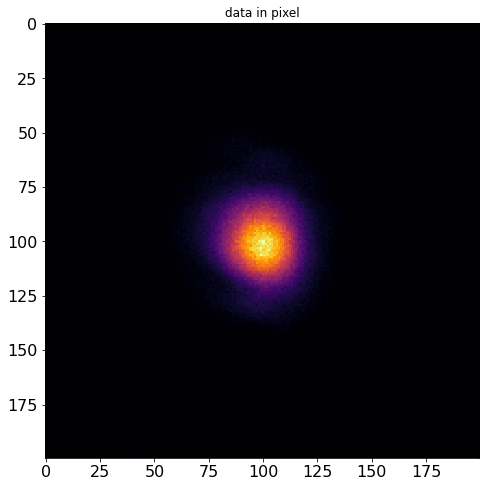

atom size in x direction: 2516.583 nm
atom size in y direction: 2736.798 nm


###########################
objective position: -480
###########################




Acquring image...




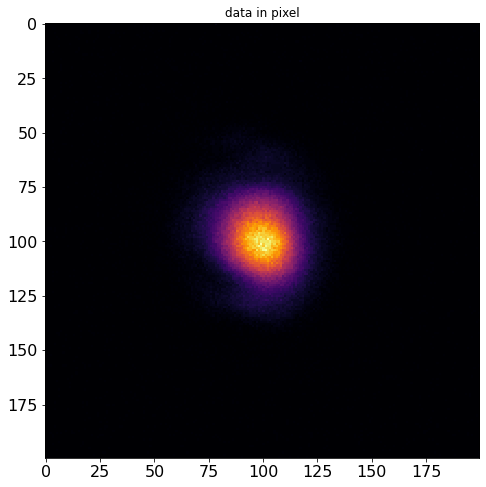

atom size in x direction: 2575.697 nm
atom size in y direction: 2837.877 nm


###########################
objective position: -460
###########################




Acquring image...




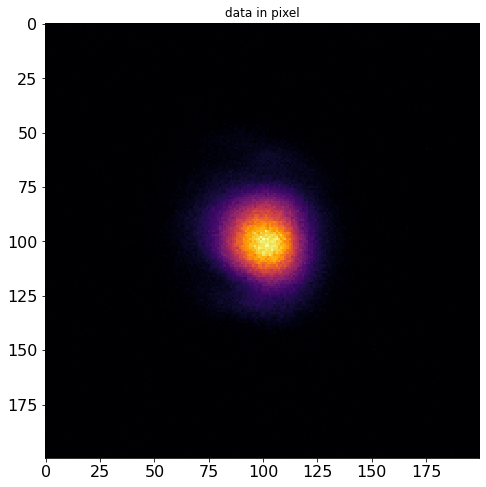

atom size in x direction: 2736.899 nm
atom size in y direction: 2851.798 nm


###########################
objective position: -440
###########################




Acquring image...




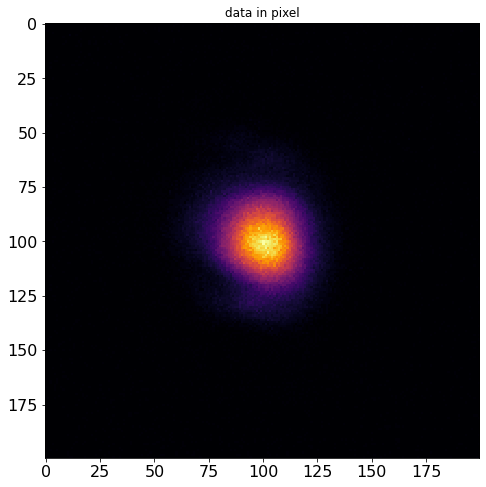

atom size in x direction: 2704.316 nm
atom size in y direction: 2886.702 nm


###########################
objective position: -420
###########################




Acquring image...




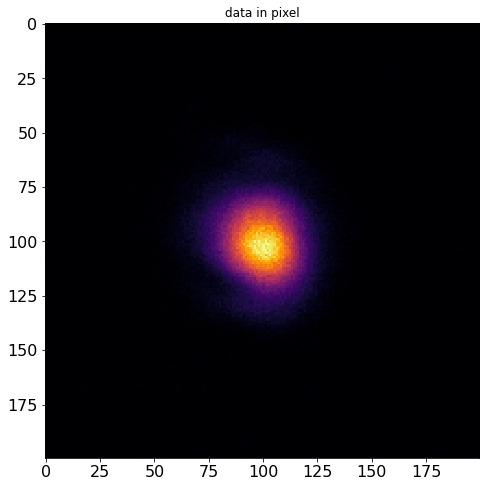

atom size in x direction: 2649.741 nm
atom size in y direction: 2902.035 nm


###########################
objective position: -400
###########################




Acquring image...




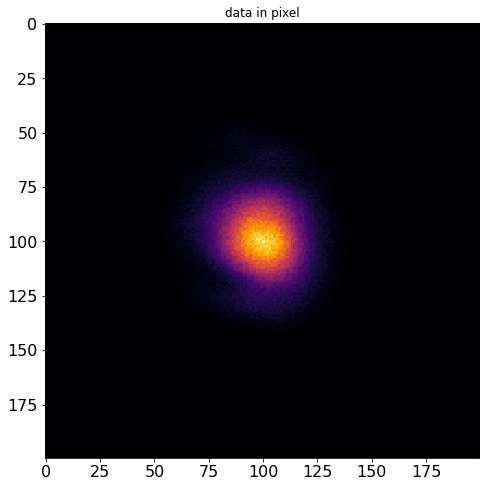

atom size in x direction: 2781.386 nm
atom size in y direction: 2952.575 nm


###########################
objective position: -380
###########################




Acquring image...




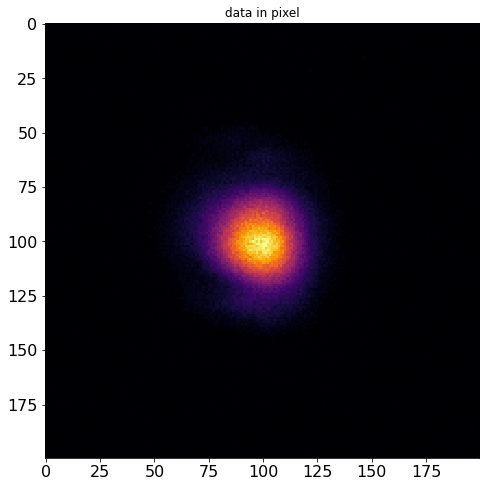

atom size in x direction: 2845.544 nm
atom size in y direction: 2957.013 nm


###########################
objective position: -360
###########################




Acquring image...




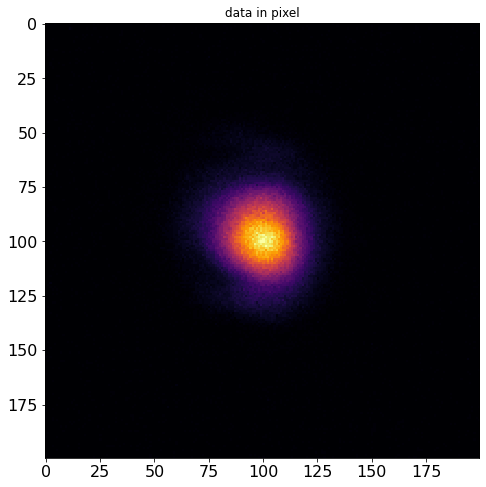

atom size in x direction: 2713.496 nm
atom size in y direction: 2901.632 nm


###########################
objective position: -340
###########################




Acquring image...




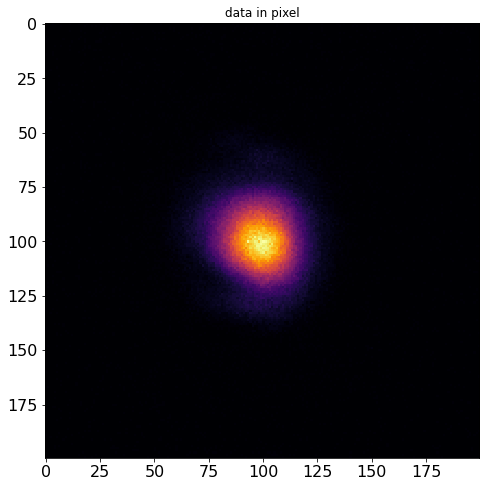

atom size in x direction: 2642.276 nm
atom size in y direction: 2810.741 nm


###########################
objective position: -320
###########################




Acquring image...




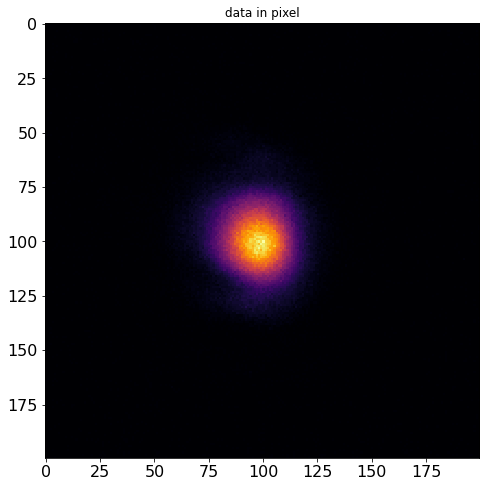

atom size in x direction: 2416.715 nm
atom size in y direction: 2676.171 nm


###########################
objective position: -300
###########################




Acquring image...




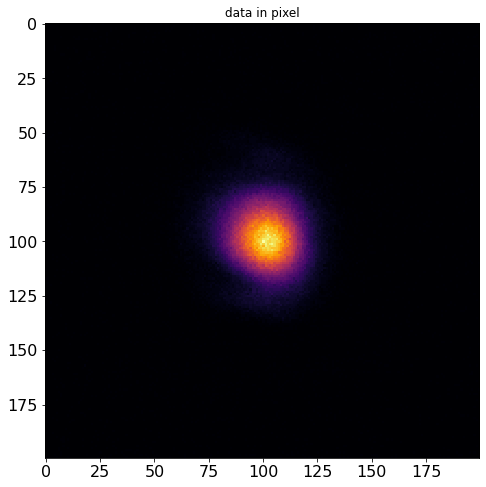

atom size in x direction: 2436.386 nm
atom size in y direction: 2596.781 nm


###########################
objective position: -280
###########################




Acquring image...




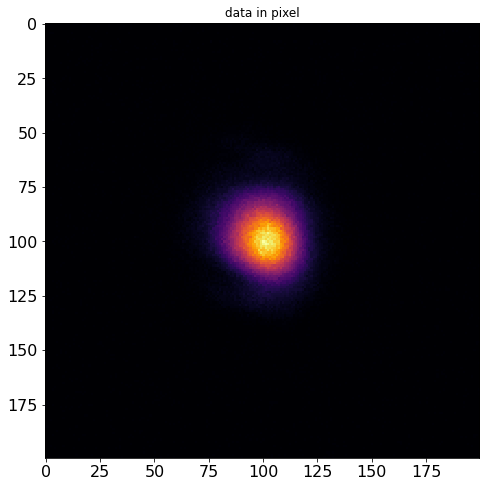

atom size in x direction: 2339.645 nm
atom size in y direction: 2489.044 nm


###########################
objective position: -260
###########################




Acquring image...




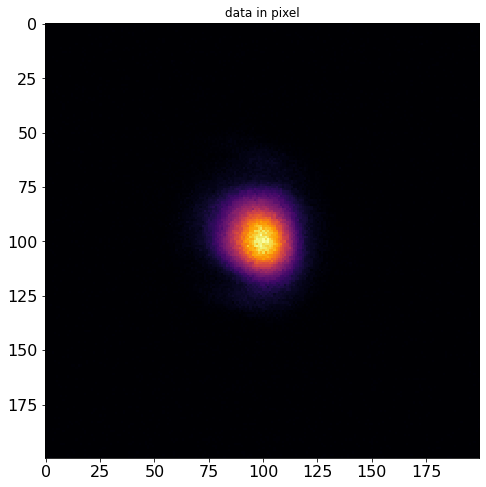

atom size in x direction: 2225.956 nm
atom size in y direction: 2442.842 nm


###########################
objective position: -240
###########################




Acquring image...




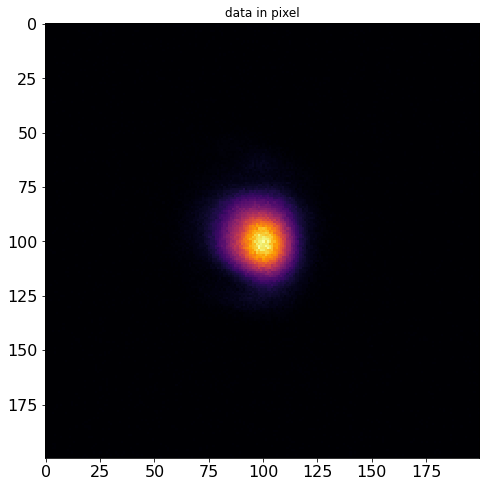

atom size in x direction: -2112.974 nm
atom size in y direction: 2257.732 nm


###########################
objective position: -220
###########################




Acquring image...




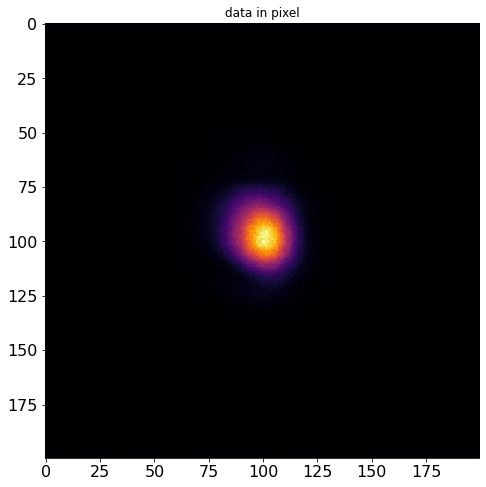

atom size in x direction: -1906.478 nm
atom size in y direction: 2131.132 nm


###########################
objective position: -200
###########################




Acquring image...




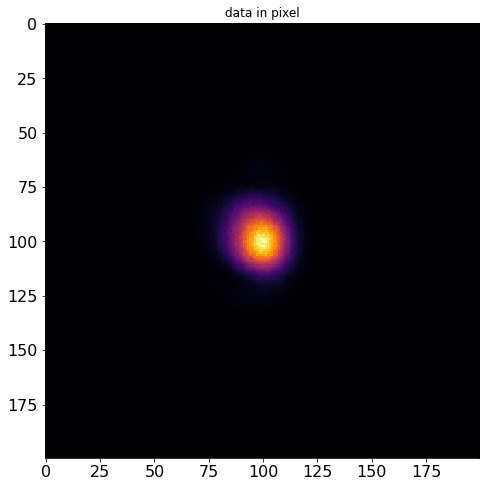

atom size in x direction: -1799.851 nm
atom size in y direction: 1995.754 nm


###########################
objective position: -180
###########################




Acquring image...




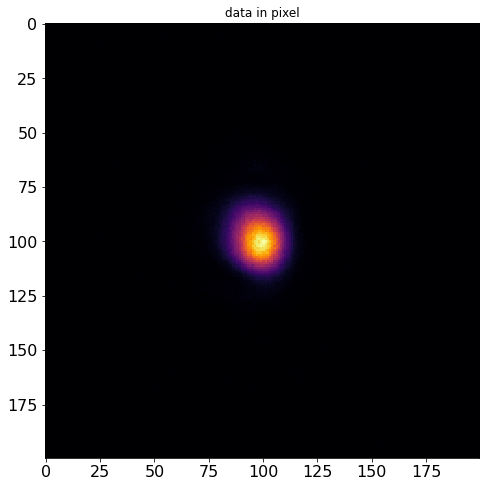

atom size in x direction: -1602.535 nm
atom size in y direction: 1854.728 nm


###########################
objective position: -160
###########################




Acquring image...




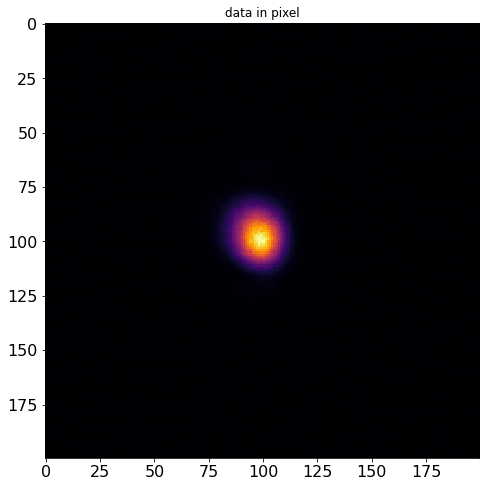

atom size in x direction: 1491.671 nm
atom size in y direction: 1693.224 nm


###########################
objective position: -140
###########################




Acquring image...




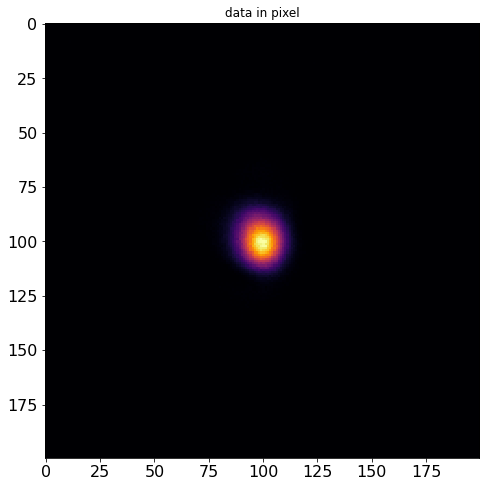

atom size in x direction: 1361.338 nm
atom size in y direction: 1571.566 nm


###########################
objective position: -120
###########################




Acquring image...




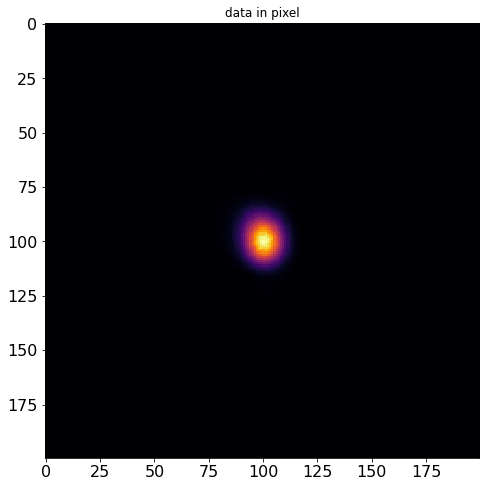

atom size in x direction: -1203.768 nm
atom size in y direction: 1438.912 nm


###########################
objective position: -100
###########################




Acquring image...




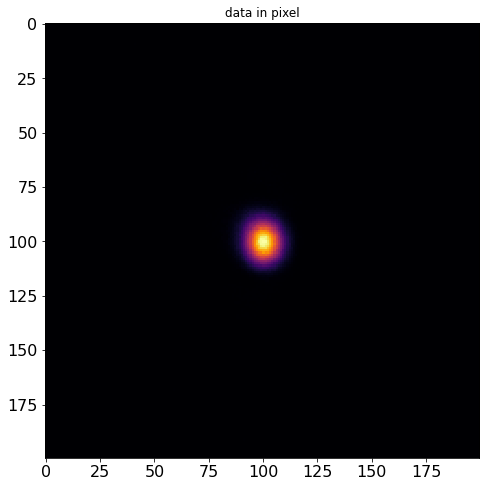

atom size in x direction: 1123.368 nm
atom size in y direction: 1319.07 nm


###########################
objective position: -80
###########################




Acquring image...




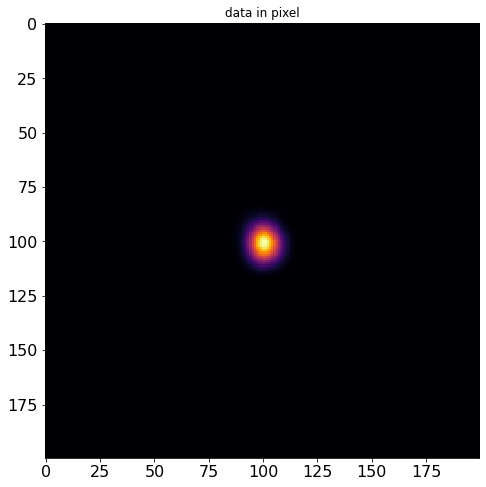

atom size in x direction: 1008.873 nm
atom size in y direction: 1184.197 nm


###########################
objective position: -60
###########################




Acquring image...




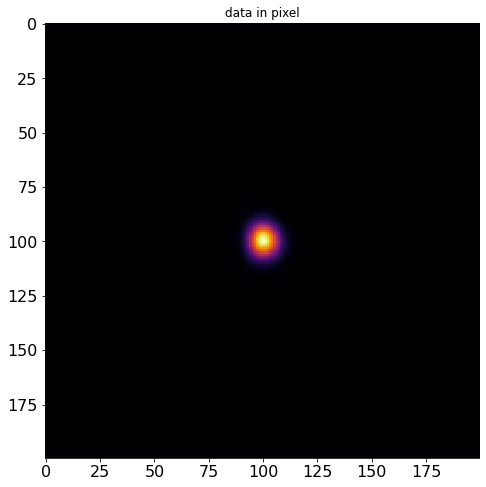

atom size in x direction: 961.763 nm
atom size in y direction: 1081.504 nm


###########################
objective position: -40
###########################




Acquring image...




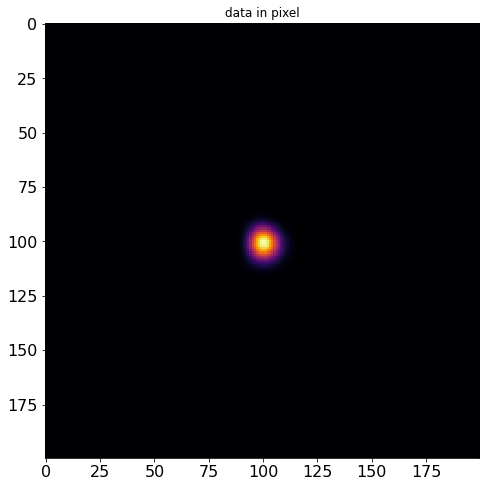

atom size in x direction: -943.908 nm
atom size in y direction: -1011.596 nm


###########################
objective position: -20
###########################




Acquring image...




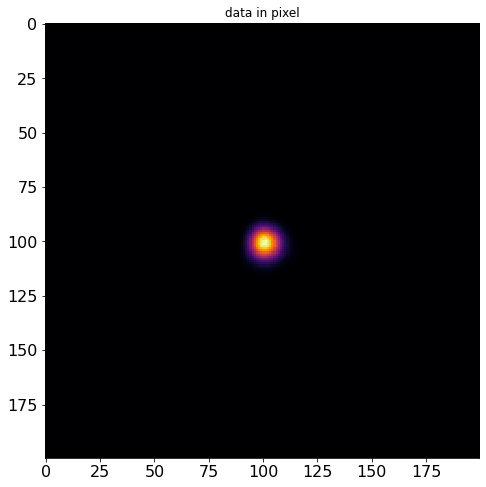

atom size in x direction: -940.781 nm
atom size in y direction: -962.167 nm


###########################
objective position: 0
###########################




Acquring image...




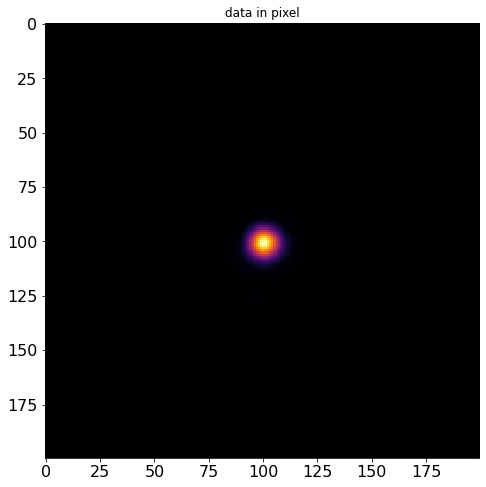

atom size in x direction: 962.368 nm
atom size in y direction: 932.105 nm


###########################
objective position: 20
###########################




Acquring image...




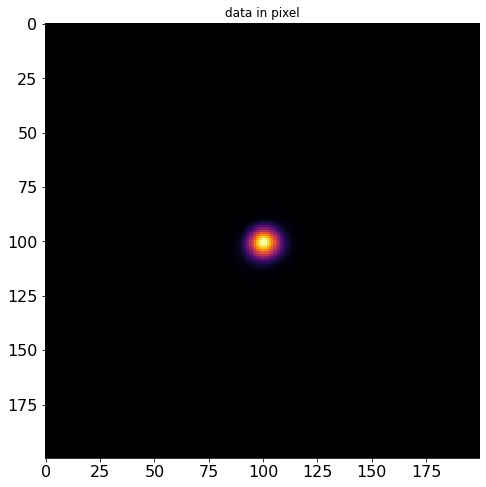

atom size in x direction: 1005.846 nm
atom size in y direction: 937.048 nm


###########################
objective position: 40
###########################




Acquring image...




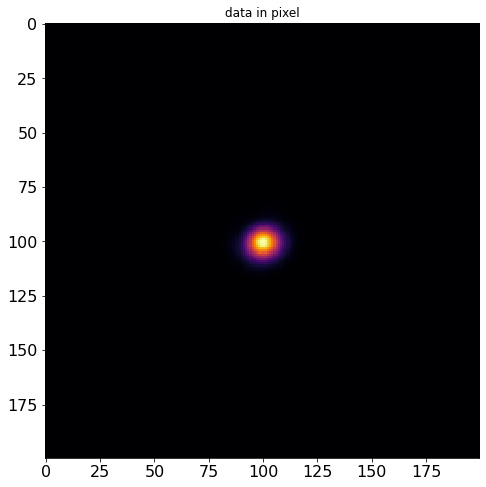

atom size in x direction: 1081.908 nm
atom size in y direction: 980.93 nm


###########################
objective position: 60
###########################




Acquring image...




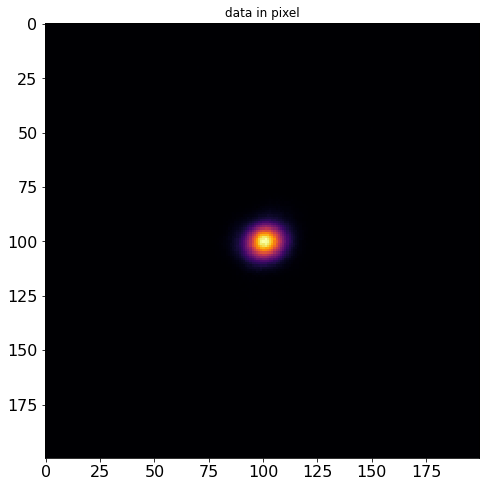

atom size in x direction: 1180.263 nm
atom size in y direction: 1056.386 nm


###########################
objective position: 80
###########################




Acquring image...




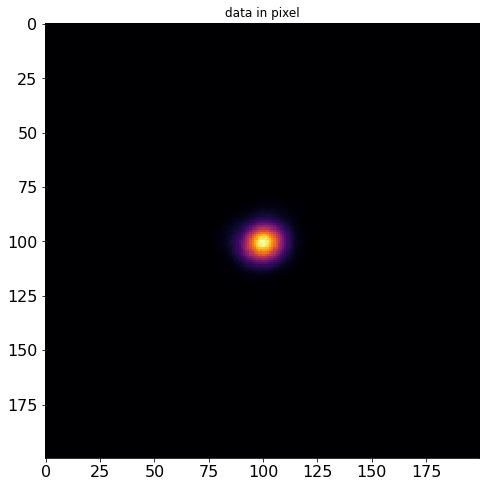

atom size in x direction: -1287.899 nm
atom size in y direction: 1154.237 nm


###########################
objective position: 100
###########################




Acquring image...




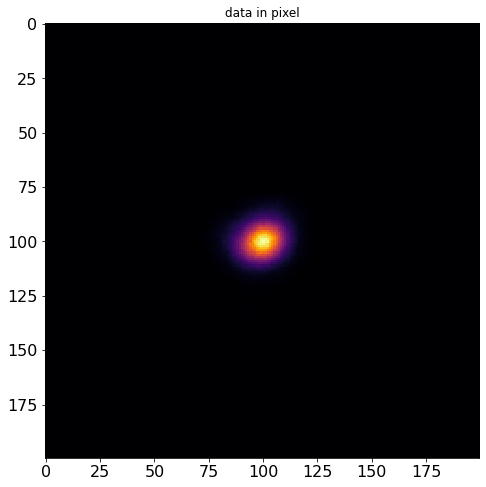

atom size in x direction: 1469.579 nm
atom size in y direction: 1296.776 nm


###########################
objective position: 120
###########################




Acquring image...




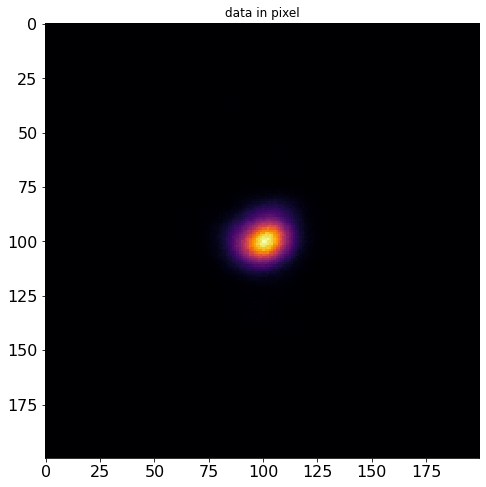

atom size in x direction: -1654.789 nm
atom size in y direction: 1447.083 nm


###########################
objective position: 140
###########################




Acquring image...




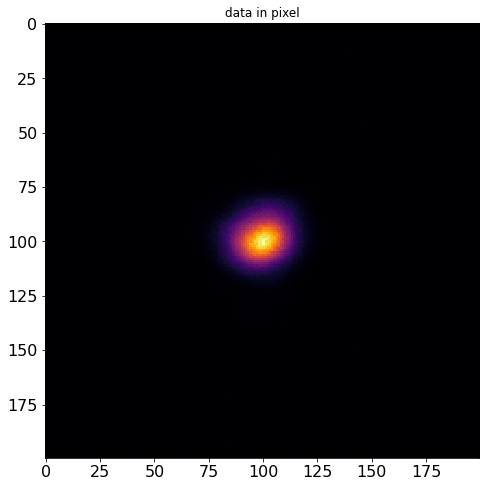

atom size in x direction: 1840.807 nm
atom size in y direction: 1624.526 nm


###########################
objective position: 160
###########################




Acquring image...




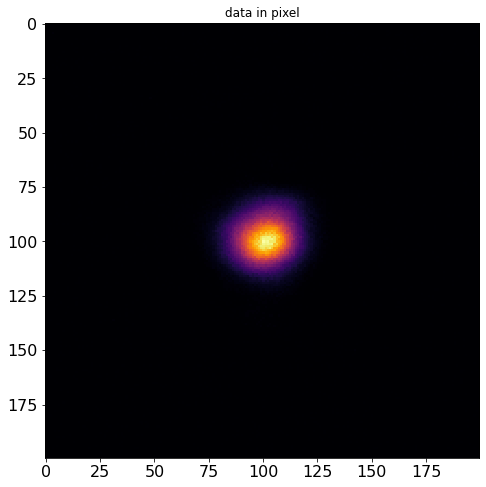

atom size in x direction: -2005.539 nm
atom size in y direction: 1799.649 nm


###########################
objective position: 180
###########################




Acquring image...




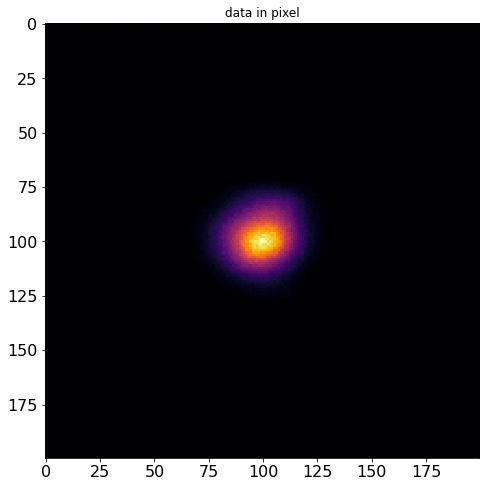

atom size in x direction: -2202.956 nm
atom size in y direction: 2000.193 nm


###########################
objective position: 200
###########################




Acquring image...




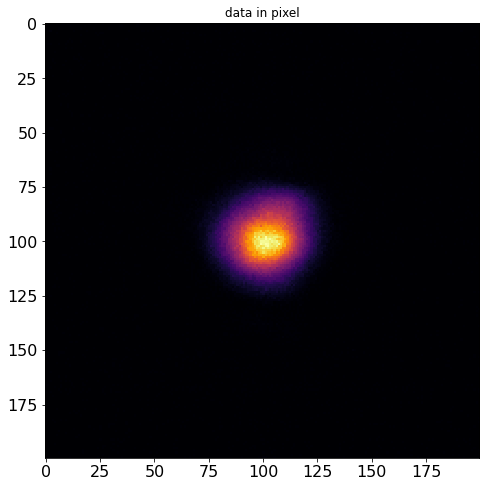

atom size in x direction: 2421.759 nm
atom size in y direction: 2250.974 nm


###########################
objective position: 220
###########################




Acquring image...




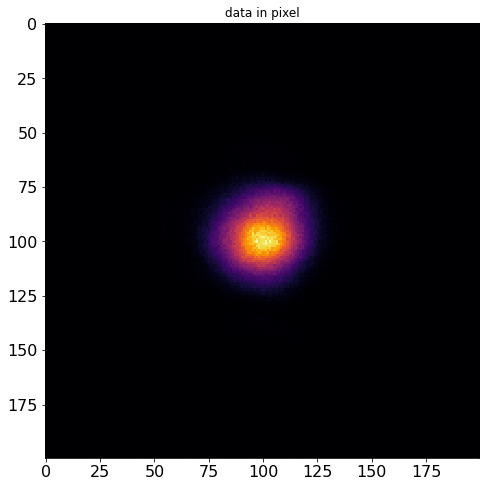

atom size in x direction: -2533.127 nm
atom size in y direction: 2393.715 nm


###########################
objective position: 240
###########################




Acquring image...




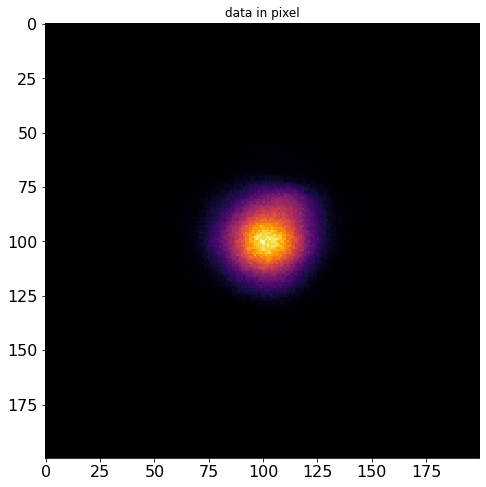

atom size in x direction: 2689.386 nm
atom size in y direction: 2588.711 nm


###########################
objective position: 260
###########################




Acquring image...




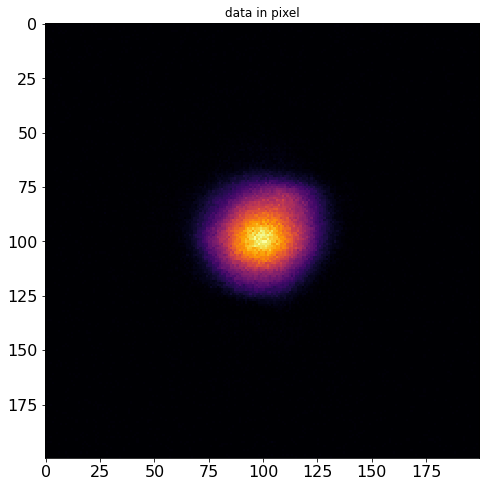

atom size in x direction: 3018.75 nm
atom size in y direction: 2812.053 nm


###########################
objective position: 280
###########################




Acquring image...




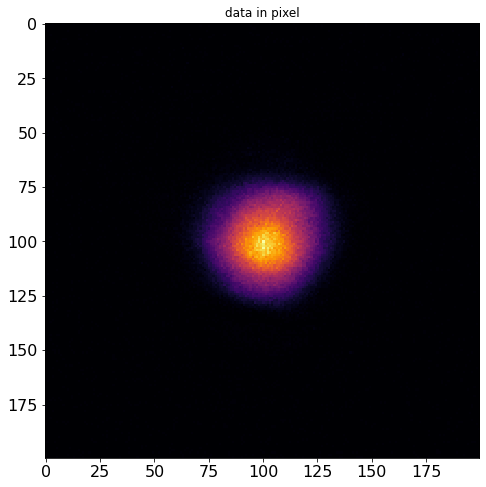

atom size in x direction: -3062.127 nm
atom size in y direction: 2989.193 nm


###########################
objective position: 300
###########################




Acquring image...




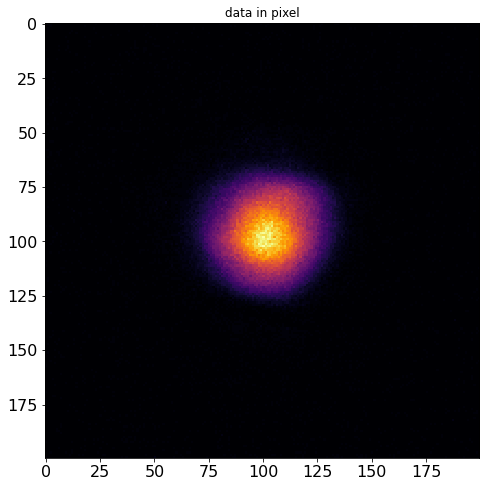

atom size in x direction: 3158.465 nm
atom size in y direction: 3126.89 nm


###########################
objective position: 320
###########################




Acquring image...




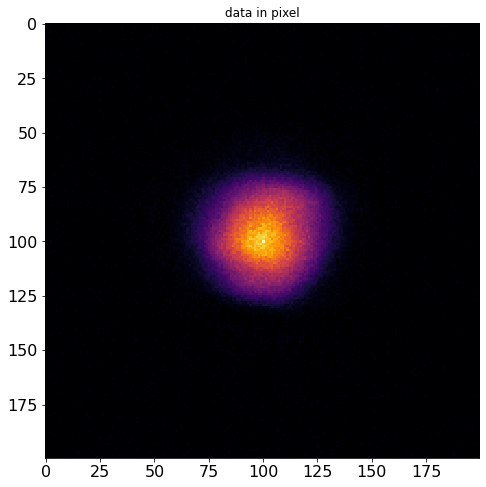

atom size in x direction: 3390.281 nm
atom size in y direction: 3330.259 nm


###########################
objective position: 340
###########################




Acquring image...




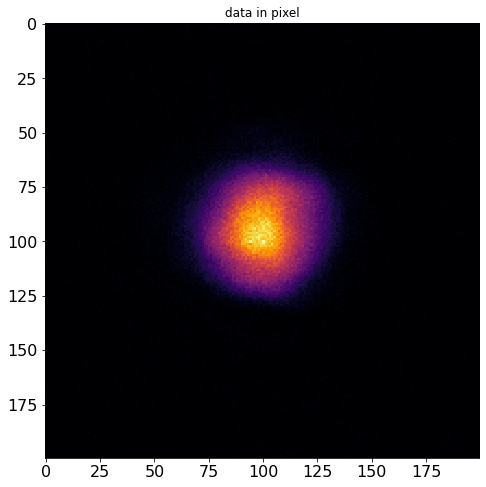

atom size in x direction: 3319.465 nm
atom size in y direction: 3495.496 nm


###########################
objective position: 360
###########################




Acquring image...




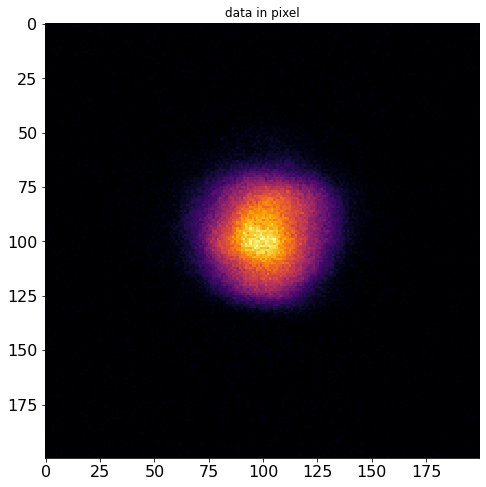

atom size in x direction: 3675.662 nm
atom size in y direction: 3707.943 nm


###########################
objective position: 380
###########################




Acquring image...




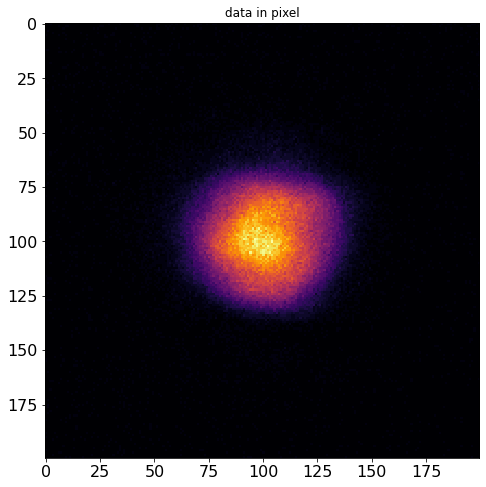

atom size in x direction: 4091.276 nm
atom size in y direction: 3854.417 nm


###########################
objective position: 400
###########################




Acquring image...




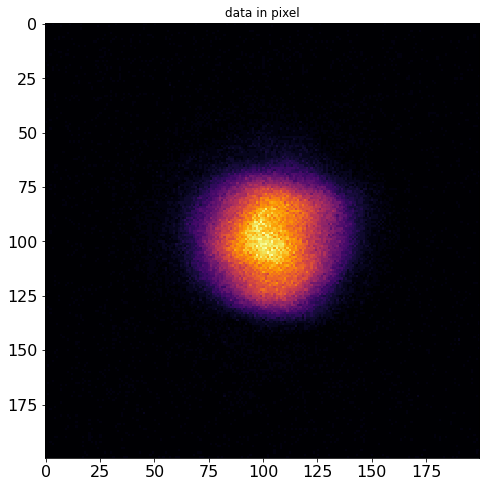

atom size in x direction: 4061.719 nm
atom size in y direction: 4088.452 nm


###########################
objective position: 420
###########################




Acquring image...




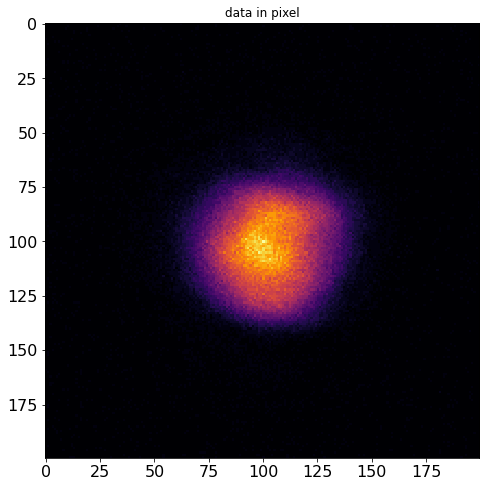

atom size in x direction: 4135.965 nm
atom size in y direction: 4155.636 nm


###########################
objective position: 440
###########################




Acquring image...




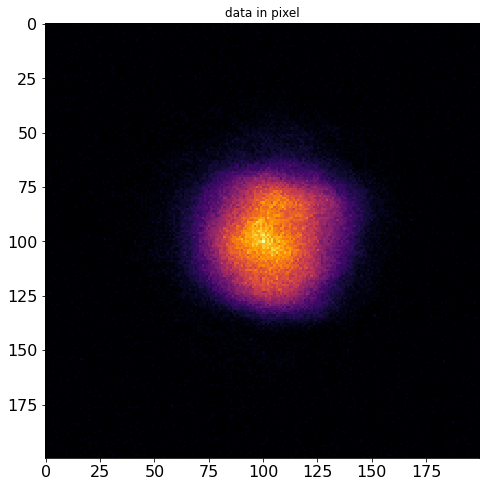

atom size in x direction: 4327.833 nm
atom size in y direction: 4318.452 nm


###########################
objective position: 460
###########################




Acquring image...




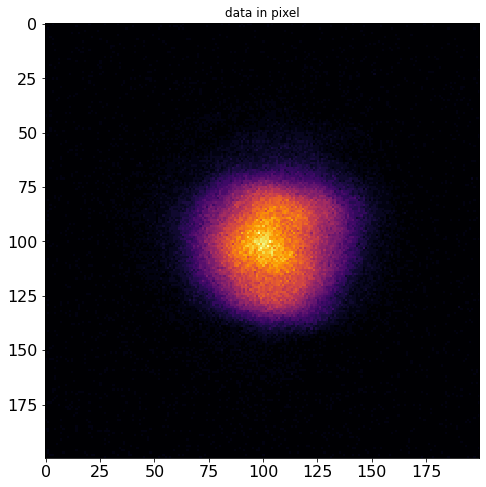

atom size in x direction: 4483.991 nm
atom size in y direction: 4379.886 nm


###########################
objective position: 480
###########################




Acquring image...




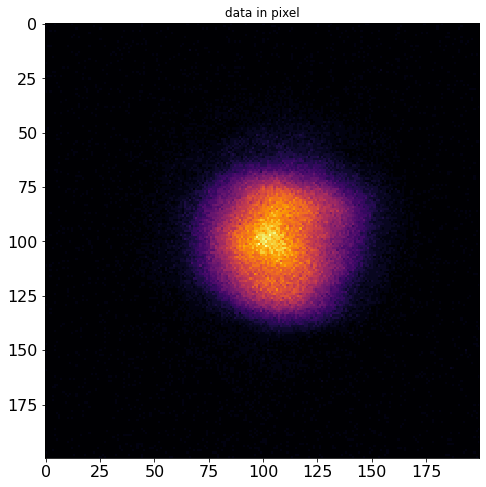

atom size in x direction: 4477.031 nm
atom size in y direction: 4554.0 nm
focus position in x direction: -75.54
focus position in y direction: -56.96
min x waist: 940.781
min y waist: 932.105


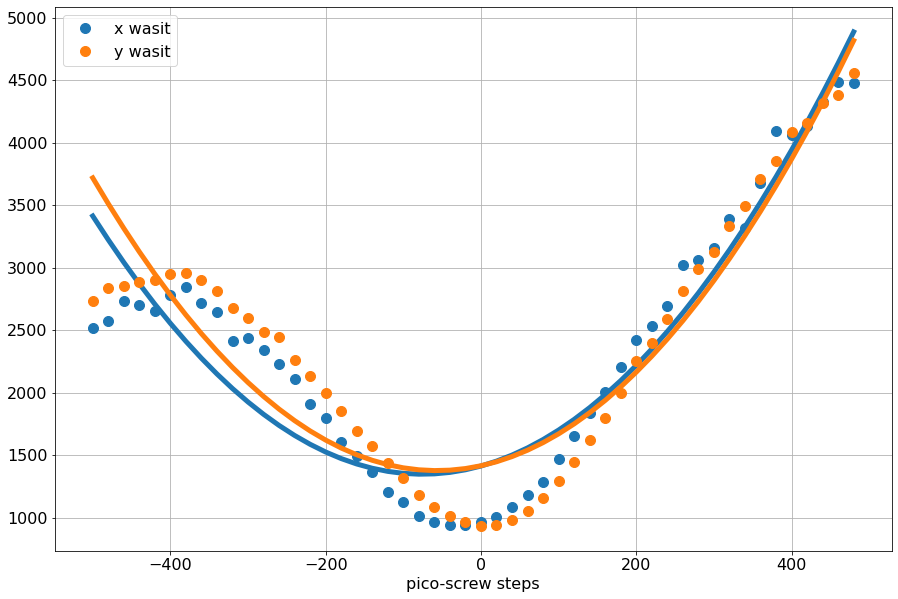

In [10]:
GAUSSIAN_FIT = True
PARABOLIC_FIT = True

x_waist = []
y_waist = []

scan_array = np.arange(-500, 500, 20)
# scan_array = np.array([0])

# we start the scan
for index in scan_array:

    # SC._open()
    print('\n')
    print('###########################')
    print(f'objective position: {index}')
    print('###########################')
    print('\n')

    cam.set_exposure(0.064*10**-3) # in seconds

    if index == scan_array[0]:
        for j in range(int(np.abs(scan_array[0])/20)):
            PM.relative_move(1, -20)
            time.sleep(0.5)
    
    elif index != scan_array[0]:
        PM.relative_move(1, +20)

    time.sleep(0.5)

    # creates the path for the image and acquires it
    file_name = datetime.datetime.now()
    file_name = "%s.%s.%s.%s.%s.%s" % (file_name.year, file_name.month, file_name.day, file_name.hour, file_name.minute, file_name.second)
    file_name = file_name + f'_special_optics_80MHz_single_tone_step={index}'
    __path__ = "//ARQUS-NAS/ArQuS Shared/Characterizations/Tweezers Analysis/real_setup/special_optics_tweezers/"
    fullpath = __path__ + str(file_name)

    print('\n')
    print('Acquring image...')
    print('\n')


    if Mako_G_158_B or Mako_G_234_B == True:
        MC.frame_grab(fullpath, 'tif')
        img = imageio.imread(fullpath + '.tif')
        img = img[:, ::-1] #mirrors the image left right
        img = imutils.rotate(img, angle=2.15)
        img = img[300:700, 1040:1900]

    elif Thor_Cam == True:
        img = cam.snap()
        img_save = Image.fromarray(img)
        img_save.save(fullpath + '.tif')
        # img = img[:, ::-1] #mirrors the image left right
        # img = imutils.rotate(img, angle=-0.1)
        x_max = int(np.mean(np.where(img == img.max())[1]))
        y_max = int(np.mean(np.where(img == img.max())[0]))
        img = img[y_max-100:y_max+100, x_max-100:x_max+100]

    # defines the grid of pixels
    rows = img.shape[0]
    cols = img.shape[1]
    x = np.arange(cols)
    y = np.arange(rows)
    x, y = np.meshgrid(x, y)
   
    # # plot the raw image
    fig, (ax1) = plt.subplots(1, figsize=(20, 8))
    ax1.imshow(img, interpolation='nearest', cmap='inferno')

    ax1.xaxis.set_tick_params(labelsize=16)
    ax1.yaxis.set_tick_params(labelsize=16)
    ax1.set_title('data in pixel')
    plt.show()


    if GAUSSIAN_FIT == True:
        # guessed parameters for the gaussians to fit
        amp = 120
        y0 = 60
        x0 = 0
        sigma_x = 5
        sigma_y = 5

        params = [amp, x0, y0, sigma_x, sigma_y] * TWEEZERS_NUMBER


        # # finds automatically the peaks
        peaks, _ = signal.find_peaks(img[y0, :], height = 40, distance = 20)

        # # build the x0 params with results found from the find_peaks function
        # for i in range(int(len(params)/5)):
        #     params[1+(i*5)] = peaks[i]
        

        # # init_guess = np.array(init_guess, dtype='float64')
        p_opt, cov = opt.curve_fit(sum_of_2D_gaussians, (x, y), img.ravel(), p0 = params)
        err = np.sqrt(np.diag(cov))
        


        amp = []
        x0 = []
        y0 = []
        sigma_x = []
        sigma_y = []

        for i in range(TWEEZERS_NUMBER):
            amp.append(p_opt[0+(i*5)])
        amp = [round(i, 3) for i in amp]

        for i in range(TWEEZERS_NUMBER):
            x0.append(p_opt[1+(i*5)])
        x0 = [round(i, 3) for i in x0]

        for i in range(TWEEZERS_NUMBER):
            y0.append(p_opt[2+(i*5)])
        y0 = [round(i, 3) for i in y0]

        for i in range(TWEEZERS_NUMBER):
            sigma_x.append(p_opt[3+(i*5)])
        sigma_x = [round(i, 3) for i in sigma_x]

        for i in range(TWEEZERS_NUMBER):
            sigma_y.append(p_opt[4+(i*5)])
        sigma_y = [round(i, 3) for i in sigma_y]


        # print(f'amplitude list: {amp}')
        # print(f'x0 list: {x0}')
        # print(f'y0 list {y0}')
        # print(f'sigma x list: {sigma_x}')
        # print(f'sigma y list: {sigma_y}')


        average_x_size = 0
        for i in range(TWEEZERS_NUMBER):
            x_size = round(1e3*sigma_x[i]*PX/MAGNIFICATION, 3)
            average_x_size += x_size
            print(f'atom size in x direction: {x_size} nm')
        average_x_size = round(average_x_size/TWEEZERS_NUMBER, 2)

        average_y_size = 0
        for i in range(TWEEZERS_NUMBER):
            y_size = round(1e3*sigma_y[i]*PX/MAGNIFICATION, 3)
            average_y_size += y_size
            print(f'atom size in y direction: {y_size} nm')
        average_y_size = round(average_y_size/TWEEZERS_NUMBER, 3)

    if PARABOLIC_FIT == True:
        screw_position = scan_array
        fit_axis = scan_array

        x_waist.append(x_size)
        y_waist.append(y_size)

if PARABOLIC_FIT == True:
    x_waist = np.abs(x_waist)
    y_waist = np.abs(y_waist)
    def parabola(x, a, b, c):
        return a*x**2 + b*x + c

    opt_x, cov_x = curve_fit(parabola, screw_position, x_waist)
    par_fit_x = parabola(fit_axis, *opt_x)

    opt_y, cov_y = curve_fit(parabola, screw_position, y_waist)
    par_fit_y = parabola(fit_axis, *opt_y)

    fig, (ax1) = plt.subplots(1, figsize=(15, 10))

    ax1.plot(screw_position, x_waist, 'o', markersize=10, label='x wasit')
    ax1.plot(fit_axis, par_fit_x, color='TAB:BLUE', linewidth = 5)
    # ax1.set_ylabel('x waist [um]', fontsize=16)
    # ax1.set_title('Fit for x waist', fontsize=16)
    ax1.xaxis.set_tick_params(labelsize=16)
    # ax1.set_yticks(range(17, 39, 3))
    ax1.yaxis.set_tick_params(labelsize=16)
    ax1.legend(fontsize=16)

    ax1.plot(screw_position, y_waist, 'o', markersize=10, label='y wasit')
    ax1.plot(fit_axis, par_fit_y, color='TAB:ORANGE', linewidth = 5)
    ax1.set_xlabel('pico-screw steps', fontsize=16)
    # ax1.set_ylabel('y waist [um]', fontsize=16)
    # ax1.set_title('Fit for y waist', fontsize=16)
    ax1.xaxis.set_tick_params(labelsize=16)
    ax1.yaxis.set_tick_params(labelsize=16)
    # ax1.set_yticks(range(17, 39, 3))
    ax1.grid()
    ax1.legend(fontsize=16)

    a_x = opt_x[0]
    b_x = opt_x[1]
    c_x = opt_x[2]

    a_y = opt_y[0]
    b_y = opt_y[1]
    c_y = opt_y[2]

    print(f'focus position in x direction: {round(-b_x/(2*a_x),2)}')
    print(f'focus position in y direction: {round(-b_y/(2*a_y), 2)}')

    print(f'min x waist: {min(x_waist)}')
    print(f'min y waist: {min(y_waist)}')


In [ ]:
ERROR

focus position in x direction: -28.94
focus position in y direction: -4.79
min x waist: 940.781
min y waist: 932.105


1.7218242672278343

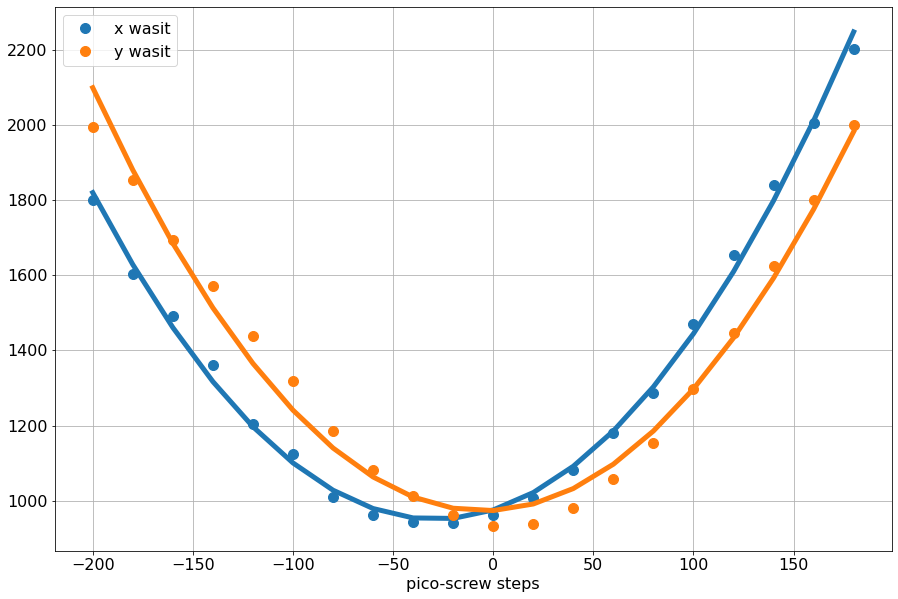

In [22]:
def parabola(x, a, b, c):
    return a*x**2 + b*x + c

screw_position_c = screw_position[15:-15]
x_waist = np.abs(x_waist)
y_waist = np.abs(y_waist)
x_waist_c = x_waist[15:-15]
y_waist_c = y_waist[15:-15]
fit_axis = screw_position_c
opt_x, cov_x = curve_fit(parabola, screw_position_c, x_waist_c)
par_fit_x = parabola(fit_axis, *opt_x)

opt_y, cov_y = curve_fit(parabola, screw_position_c, y_waist_c)
par_fit_y = parabola(fit_axis, *opt_y)

fig, (ax1) = plt.subplots(1, figsize=(15, 10))

ax1.plot(screw_position_c, np.abs(x_waist_c), 'o', markersize=10, label='x wasit')
ax1.plot(fit_axis, par_fit_x, color='TAB:BLUE', linewidth = 5)
ax1.set_xlabel('pico-screw steps', fontsize=16)
# ax1.set_ylabel('x waist [um]', fontsize=16)
# ax1.set_title('Fit for x waist', fontsize=16)
ax1.xaxis.set_tick_params(labelsize=16)
# ax1.set_yticks(range(17, 39, 3))
ax1.yaxis.set_tick_params(labelsize=16)
ax1.legend(fontsize=16)

ax1.plot(screw_position_c, np.abs(y_waist_c), 'o', markersize=10, label='y wasit')
ax1.plot(fit_axis, par_fit_y, color='TAB:ORANGE', linewidth = 5)
# ax1.set_ylabel('y waist [um]', fontsize=16)
# ax1.set_title('Fit for y waist', fontsize=16)
ax1.xaxis.set_tick_params(labelsize=16)
ax1.yaxis.set_tick_params(labelsize=16)
# ax1.set_yticks(range(17, 39, 3))
ax1.grid()
ax1.legend(fontsize=16)

a_x = opt_x[0]
b_x = opt_x[1]
c_x = opt_x[2]

a_y = opt_y[0]
b_y = opt_y[1]
c_y = opt_y[2]

print(f'focus position in x direction: {round(-b_x/(2*a_x),2)}')
print(f'focus position in y direction: {round(-b_y/(2*a_y), 2)}')

print(f'min x waist: {min(x_waist_c)}')
print(f'min y waist: {min(y_waist_c)}')

b_x

In [ ]:
x_waist

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

__path__ = "//ARQUS-NAS/ArQuS Shared/Characterizations/Tweezers Analysis/real_setup/mitutoyo_tweezers/"

def load_and_crop_image(step):
    filename = f'2024.3.28_mitutoyo_80MHz_single_tone_step={step}'
    fullpath = f'{__path__}{filename}.tif'
    img = imageio.imread(fullpath)
    return img[380:610, 710:960]

scan_array = np.arange(-500, 501, 35*2)

img_list = []
# Load images for different steps
for i in range(len(scan_array)):
    img_list.append(load_and_crop_image(scan_array[i]))




# Create a figure with custom positions for each subplot
fig, axs = plt.subplots(1, len(scan_array), figsize=(30, 6), gridspec_kw={'width_ratios': [1]*len(scan_array)})

# Plot images on subplots
for ax, img, step in zip(axs, img_list, scan_array):
    ax.imshow((img), cmap='cividis')
    ax.set_title(f'z={step}', fontsize=16)

    # Change the edge thickness and color of the subplot
    ax.spines['left'].set(lw=4, color='khaki')
    ax.spines['right'].set(lw=4, color='khaki')
    ax.spines['top'].set(lw=4, color='khaki')
    ax.spines['bottom'].set(lw=4, color='khaki')

    ax.set_xticks([])
    ax.set_yticks([])

fig.text(0.5, 0.25, 'Steps', ha='center', fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
ERROR

In [ ]:
import matplotlib.pyplot as plt
import cv2 as cv
import imageio
import numpy as np

fig, (ax1) = plt.subplots(1, figsize=(20, 15))
img = imageio.imread('//ARQUS-NAS/ArQuS Shared/Characterizations/Tweezers Analysis/test_setup/tweezers_image/defocus_scan/single_tweezer_special_optics_olympus_t=0.065_gain=0_step=240_v3.tif')
img = img[150:270, 650:750]
ax1.imshow(np.log(img), cmap='cividis')